# CNN Image Classification Practice

This notebook covers:
- **Practice 1:** Load, visualize, and normalize the dataset
- **Practice 2:** Build a simple CNN (Conv → Pool → Flatten → Dense → Output)
- **Practice 3:** Evaluate the trained model (accuracy, loss, sample predictions)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Practice 1: Load, visualize, and normalize the dataset

In [17]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)


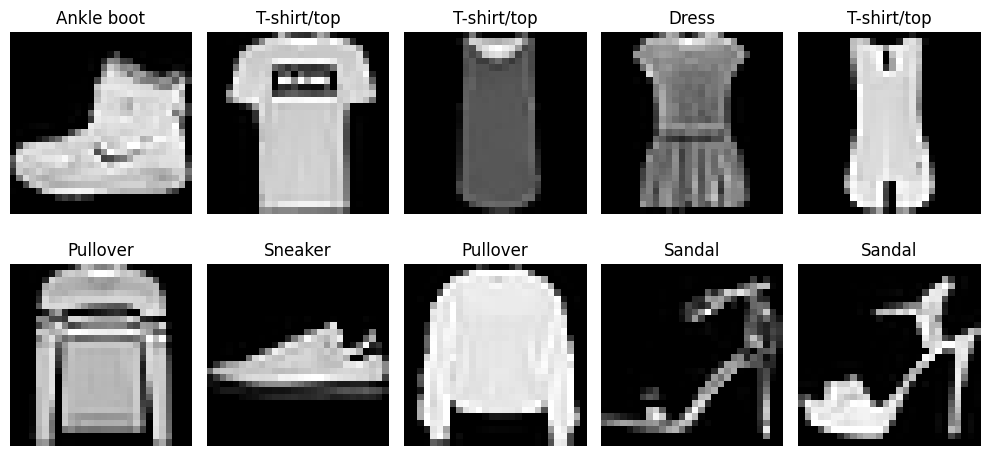

In [18]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
x_train = x_train/ 255.0
x_test = x_test/ 255.0

# CNNs expect a channel dimension: (height, width, channels)
# Fashion MNIST is grayscale, so channels = 1
x_train = np.expand_dims(x_train, axis=-1)  # shape becomes (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)    # shape becomes (10000, 28, 28, 1)

print(f"After normalization -> min: {x_train.min()}, max: {x_train.max()}")
print(f"New training shape (with channel dim): {x_train.shape}")

After normalization -> min: 0.0, max: 1.0
New training shape (with channel dim): (60000, 28, 28, 1)


Practice 2: Build a simple CNN (Conv → Pool → Flatten → Dense → Output)

In [20]:
model = keras.Sequential([
    # Convolution Layer: 32 filters, 3x3 kernel, ReLU activation
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),

    # Max Pooling Layer: reduces spatial dimensions taking the max in 2x2 patch
    layers.MaxPooling2D(pool_size=(2, 2)),

    # A second convolution + pooling block improves feature extraction
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten Layer converts 3D feature maps into a 1D vector
    layers.Flatten(),

    # Dense (Fully Connected) Layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),  # helps reduce overfitting

    # Output Layer: 10 classes softmax gives a probability distribution
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # labels are integers, not one-hot
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.8081 - loss: 0.5281 - val_accuracy: 0.8678 - val_loss: 0.3563
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.8705 - loss: 0.3557 - val_accuracy: 0.8847 - val_loss: 0.3169
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.8880 - loss: 0.3054 - val_accuracy: 0.8881 - val_loss: 0.2960
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9000 - loss: 0.2738 - val_accuracy: 0.8900 - val_loss: 0.2946
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9077 - loss: 0.2499 - val_accuracy: 0.9060 - val_loss: 0.2540
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9165 - loss: 0.2273 - val_accuracy: 0.9052 - val_loss: 0.2602
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9224 - loss: 0.2112 - val_accuracy: 0.9041 - val_loss: 0.2583
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9275 -

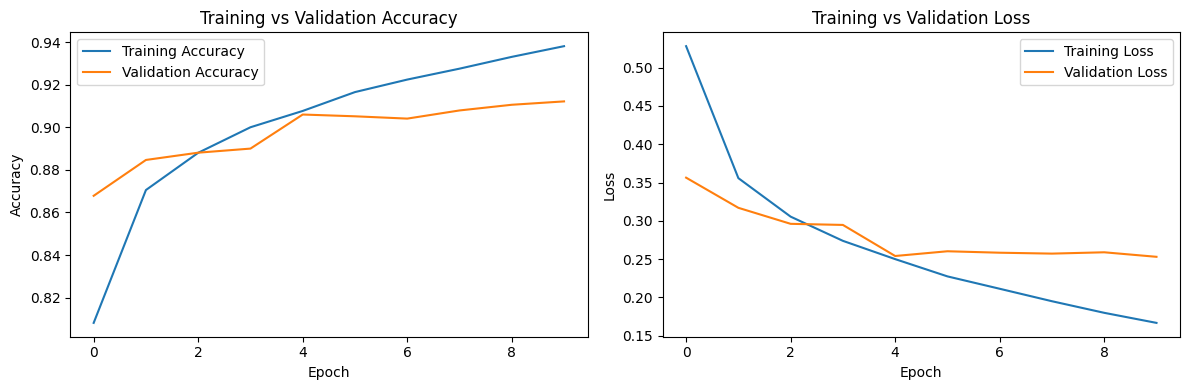

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

Practice 3: Evaluate the Trained Model

In [23]:
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Training Loss: {train_loss:.4f}")

Final Training Accuracy: 0.9468
Final Training Loss: 0.1450


In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9083
Test Loss: 0.2699


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


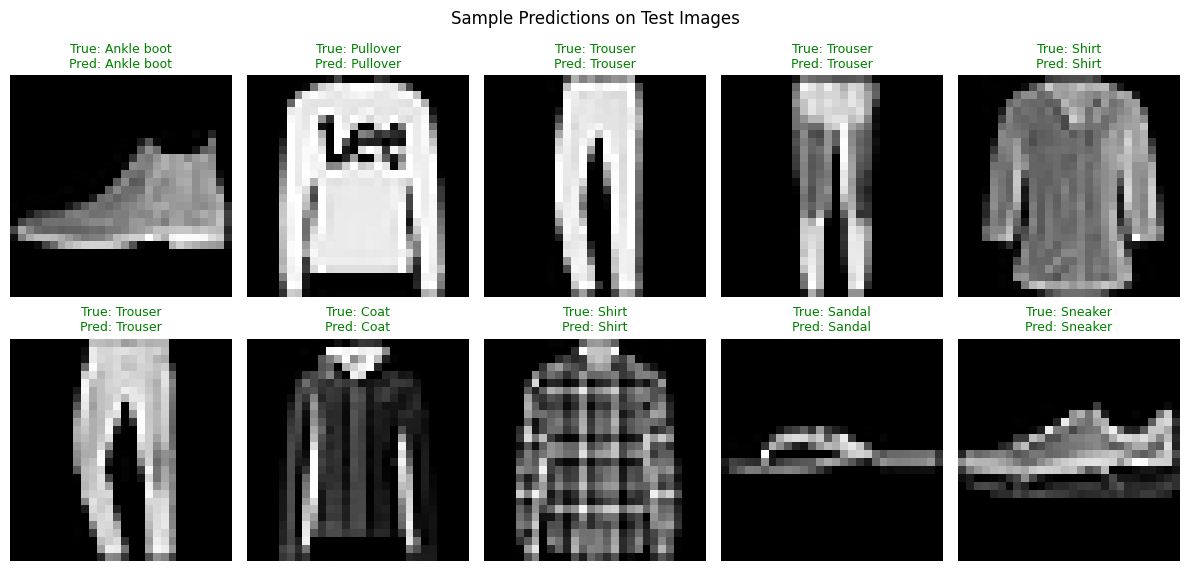

In [27]:
predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    true_label = class_names[y_test[i]]
    pred_label = class_names[predicted_labels[i]]
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Predictions on Test Images")
plt.tight_layout()
plt.show()